# Swiggy Restaurant Data – Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to analyze Swiggy restaurant data to answer key business questions related to city-wise restaurant distribution, rating trends, and the relationship between pricing and customer satisfaction using Python-based exploratory data analysis.

<img src="swiggy.jpeg" height="200px">

In [1]:
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Dataset Overview

The dataset contains restaurant-level information from Swiggy, including:

- Restaurant name and location (Area, City)
- Pricing details
- Average customer rating
- Total number of ratings
- Cuisine type
- Estimated delivery time

This dataset enables analysis of city-wise restaurant distribution, pricing trends, and the relationship between cost and customer satisfaction.

In [2]:
df = pd.read_csv('swiggy.csv')
df.head()

,ID,Area,City,Restaurant,Price,Avg ratings,Total ratings,Food type,Address,Delivery time
0,211,Koramangala,Bangalore,Tandoor Hut,300,4.4,100,"Biryani,Chinese,North Indian,South Indian",5Th Block,59
1,221,Koramangala,Bangalore,Tunday Kababi,300,4.1,100,"Mughlai,Lucknowi",5Th Block,56
2,246,Jogupalya,Bangalore,Kim Lee,650,4.4,100,Chinese,Double Road,50
3,248,Indiranagar,Bangalore,New Punjabi Hotel,250,3.9,500,"North Indian,Punjabi,Tandoor,Chinese",80 Feet Road,57
4,249,Indiranagar,Bangalore,Nh8,350,4.0,50,"Rajasthani,Gujarati,North Indian,Snacks,Desser...",80 Feet Road,63


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8680 entries, 0 to 8679
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             8680 non-null   int64  
 1   Area           8680 non-null   object 
 2   City           8680 non-null   object 
 3   Restaurant     8680 non-null   object 
 4   Price          8680 non-null   int64  
 5   Avg ratings    8680 non-null   float64
 6   Total ratings  8680 non-null   int64  
 7   Food type      8680 non-null   object 
 8   Address        8680 non-null   object 
 9   Delivery time  8680 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 678.3+ KB


### Dataset Structure Summary

- The dataset contains 8,680 restaurant records and 10 columns.
- There are no missing values in any column.
- The dataset includes a mix of numerical (Price, Avg ratings, Total ratings, Delivery time) and categorical features (City, Area, Food type).
- Data types appear appropriate for analysis.

## Data Cleaning and Validation
In this step, missing values and duplicate records are checked to ensure data quality.

In [5]:
# check null values
df.isnull().sum()

ID               0
Area             0
City             0
Restaurant       0
Price            0
Avg ratings      0
Total ratings    0
Food type        0
Address          0
Delivery time    0
dtype: int64

In [6]:
# duplicate
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
8675    False
8676    False
8677    False
8678    False
8679    False
Length: 8680, dtype: bool

Observation:
- No significant missing or duplicate values were found.
- Hence, no rows were removed to preserve data integrity.

In [7]:
# check stats
df.describe()

,ID,Price,Avg ratings,Total ratings,Delivery time
count,8680.000000,8680.000000,8680.000000,8680.000000,8680.000000
mean,244812.071429,348.444470,3.655104,156.634793,53.967051
std,158671.617188,230.940074,0.647629,391.448014,14.292335
min,211.000000,0.000000,2.000000,20.000000,20.000000
25%,72664.000000,200.000000,2.900000,50.000000,44.000000
50%,283442.000000,300.000000,3.900000,80.000000,53.000000
75%,393425.250000,400.000000,4.200000,100.000000,64.000000
max,466928.000000,2500.000000,5.000000,10000.000000,109.000000


## Key Business Questions
1. Which cities have the highest number of restaurants on Swiggy?
2. How are restaurant ratings distributed?
3. Is there a relationship between restaurant pricing and ratings?
4. Do ratings vary significantly across different cities?

In [8]:
top_cities = df['City'].value_counts().head(10).reset_index()
top_cities.columns = ['City', 'Number of Restaurants']

px.bar(
    top_cities,
    x='City',
    y='Number of Restaurants',
    title="Top 10 Cities by Number of Restaurants"
)

### Insight

Kolkata and Mumbai have the highest number of listed restaurants, indicating strong Swiggy penetration in major metropolitan areas.  
This suggests that urban markets contribute significantly to overall platform presence.

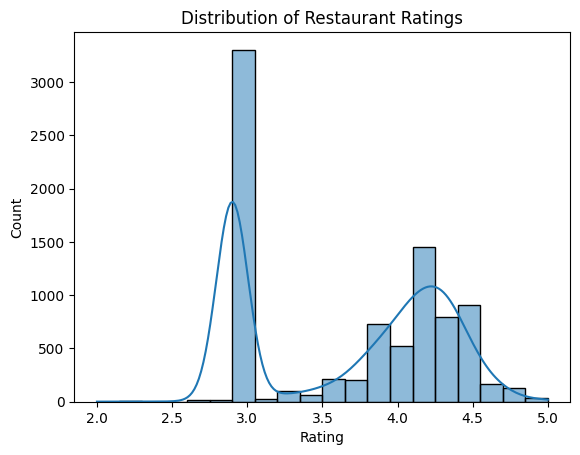

In [9]:
sns.histplot(df['Avg ratings'], bins=20, kde=True)
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Insight
Most restaurants have ratings between **3.5 and 4.5**, showing generally positive
customer feedback across the platform.

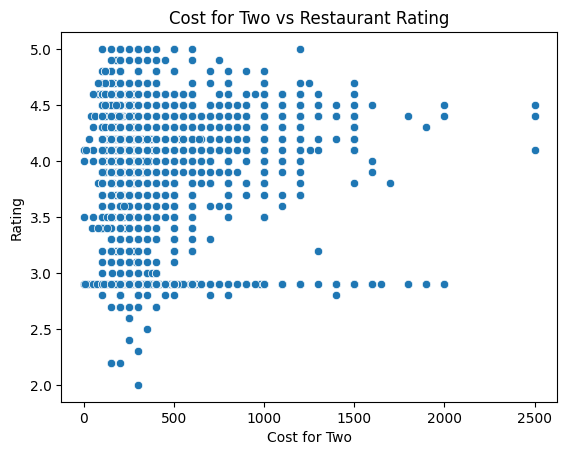

In [10]:
sns.scatterplot(x=df['Price'], y=df['Avg ratings'])
plt.title("Cost for Two vs Restaurant Rating")
plt.xlabel("Cost for Two")
plt.ylabel("Rating")
plt.show()

### Insight
There is no strong correlation between pricing and ratings, suggesting that
higher prices do not necessarily guarantee better customer satisfaction.

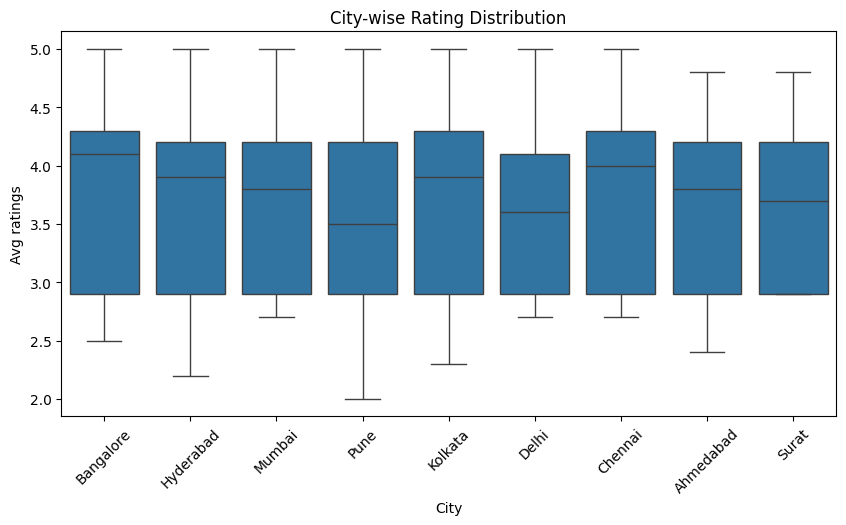

In [11]:
top_cities = df['City'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.boxplot(x='City', y='Avg ratings', data=df[df['City'].isin(top_cities.index)])
plt.xticks(rotation=45)
plt.title("City-wise Rating Distribution")
plt.show()

### Insight
Ratings across cities show similar distributions, indicating consistent service
quality standards regardless of location.

## Key Insights & Conclusion
- Urban cities dominate Swiggy’s restaurant listings.
- Most restaurants maintain ratings above 3.5.
- Pricing has a weak relationship with customer ratings.
- Customer satisfaction is influenced more by service quality than cost.

This analysis can help food delivery platforms and restaurants optimize pricing
and improve customer experience strategies.